# Symmetric-projected ABBA guiding-center symplecticity study

This experiment evaluates the physical guiding-center map produced by `SymmetricProjectedABBA`, the second-order endpoint-time ABBA splitting closed by Hairer's symmetric projection. For a step $h$ with $s=h/2$, the duplicated state follows $A_{s,t_n}$, $B_{s,t_n}$, $B_{s,t_n+h}$, and $A_{s,t_n+h}$. The projection multiplier solves

$$R(\mu)=u^{(2)}(\mu)-v^{(2)}(\mu)+2\mu=0,$$

using the exact state-dependent residual Jacobian derived in `docs/tex/ABBA_implicit/ABBA_implicit.tex`.

For every complete finite-tolerance ABBA step, this study differentiates the emitted numerical map by centered finite differences. If $J_n$ is one step Jacobian and $DG_n$ is the accumulated Jacobian from the initial condition, the recorded defects are

$$\varepsilon_{\mathrm{local},n}=\frac{\|J_n^T\Omega J_n-\Omega\|_F}{\|\Omega\|_F},\qquad \varepsilon_{\mathrm{flow},n}=\frac{\|DG_n^T\Omega DG_n-\Omega\|_F}{\|\Omega\|_F}.$$

The transported polygon area, $|\det(DG_n)-1|$, Newton residuals, iteration counts, and projection multipliers provide complementary geometric and nonlinear-solver diagnostics.

In [1]:
import numpy as np

from studies import (
    ABBASymplecticityConfig,
    RandomPotentialConfig,
    centered_circle,
    pi_area_steps,
    run_abba_symplecticity_study,
)
from visualization import display_animation

## Reproducible configuration

The potential, boundary geometry, physical parameters, integration interval, three ABBA steps, observation interval, finite-difference scale, and Newton stopping parameters are explicit below. The physical configuration and differentiation scale match the RK4 experiment in this directory so their defect magnitudes can be compared directly.

In [2]:
potential_config = RandomPotentialConfig(
    amplitude=0.7,
    max_wave_number=25,
    nx=64,
    ny=64,
    seed=27,
    interpolation_order=5,
)
potential = potential_config.build()

circle_radius = 0.5
circle_points = 16
rho = 0.3
circle = centered_circle(
    potential,
    radius=circle_radius,
    points=circle_points,
    rho=rho,
)

finite_difference_relative_step = float(np.cbrt(np.finfo(float).eps))
study_config = ABBASymplecticityConfig(
    steps=pi_area_steps(40, 80, 160),
    t_span=(0.0, 4 * np.pi),
    save_interval=np.pi / 8,
    chunk_size=16,
    progress=True,
    block_prefix="symmetric_projected_abba_symplecticity",
    finite_difference_relative_step=finite_difference_relative_step,
    newton_absolute_tolerance=1e-13,
    newton_relative_tolerance=1e-12,
    newton_max_iterations=12,
)

print(potential_config)
print(study_config)
print(
    f"Circle: {circle_points} points; t={study_config.t_span}; "
    f"{study_config.output_sample_count} saved states; "
    f"finite-difference relative step={finite_difference_relative_step:.8e}"
)

RandomPotentialConfig(amplitude=0.7, max_wave_number=25, nx=64, ny=64, seed=27, interpolation_order=5)
ABBASymplecticityConfig(steps=(AreaStep(label='$\\Delta t=\\pi/40$', value=0.07853981633974483), AreaStep(label='$\\Delta t=\\pi/80$', value=0.039269908169872414), AreaStep(label='$\\Delta t=\\pi/160$', value=0.019634954084936207)), t_span=(0.0, 12.566370614359172), save_interval=0.39269908169872414, rho=None, chunk_size=16, progress=True, block_prefix='symmetric_projected_abba_symplecticity', finite_difference_relative_step=6.0554544523933395e-06, newton_absolute_tolerance=1e-13, newton_relative_tolerance=1e-12, newton_max_iterations=12)
Circle: 16 points; t=(0.0, 12.566370614359172); 33 saved states; finite-difference relative step=6.05545445e-06


## Projected ABBA integrations and persisted Jacobians

Newton starts from $\mu_0=0$ on every step, uses the infinity norm for its stopping test, and reevaluates the exact residual Jacobian after each correction. Every main-grid ABBA step contributes to the accumulated finite-difference Jacobian. Scalar diagnostics and full local and accumulated Jacobians are persisted at the common observation times.

In [3]:
result = run_abba_symplecticity_study(
    potential,
    circle,
    notebook_path=(
        "notebooks/experiments/symplecticity/"
        "gc_area_and_symmetric_projected_abba_symplecticity.ipynb"
    ),
    config=study_config,
    metadata={
        **potential_config.metadata(),
        "circle_radius": circle_radius,
        "study_kind": "versioned_symplecticity_experiment",
    },
)
result.print_summary()

SymmetricProjectedABBA [==============================] 100.0% (160/160, t=12.5664)
SymmetricProjectedABBA [==============================] 100.0% (320/320, t=12.5664)
SymmetricProjectedABBA [==============================] 100.0% (640/640, t=12.5664)


                  step SymmetricProjectedABBA steps     max |area error|     max local defect      max flow defect      max |det-1|
     $\Delta t=\pi/40$                          160       1.77718737e-02       1.27700517e-10       4.15792547e-09   6.62278743e-09
     $\Delta t=\pi/80$                          320       1.77812418e-02       6.04799090e-11       4.02612242e-09   6.43801878e-09
    $\Delta t=\pi/160$                          640       1.77835883e-02       4.10144887e-11       4.08061398e-09   6.00487460e-09

Nonlinear projection solve per main integration step:
  $\Delta t=\pi/40$: max/mean iterations=2/1.006, max residual=3.547e-12, max |mu|_inf=2.807e-05
  $\Delta t=\pi/80$: max/mean iterations=1/1.000, max residual=1.318e-14, max |mu|_inf=3.712e-06
  $\Delta t=\pi/160$: max/mean iterations=1/1.000, max residual=2.781e-15, max |mu|_inf=4.686e-07

The observer differentiates the emitted finite-tolerance ABBA map by centered differences. The reported defects include diff

## Time-dependent diagnostics

The local matrix defect tests each projected ABBA step independently. The accumulated defect and determinant error test the complete discrete flow from the initial boundary, while the area panel shows the transported polygon geometry.

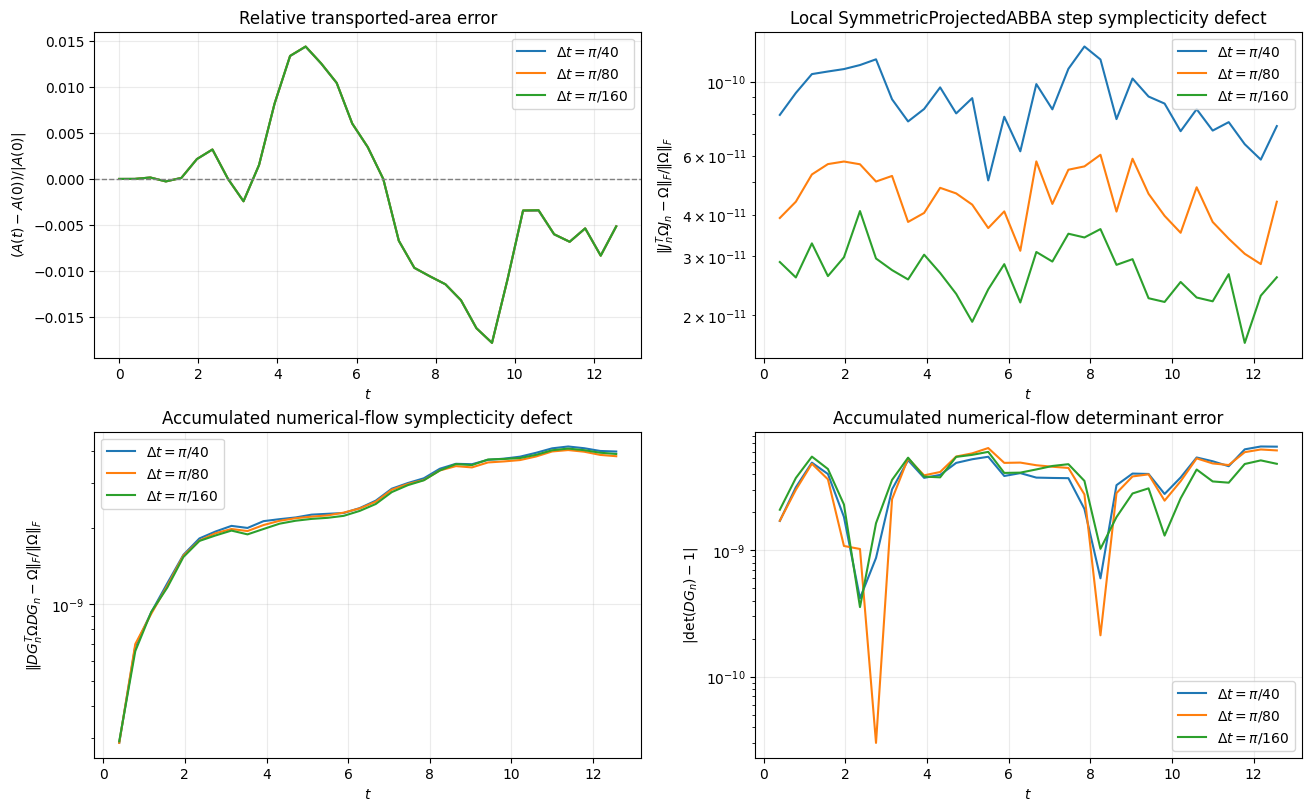

In [4]:
diagnostic_figure, diagnostic_axes = result.plot_diagnostics()

## Measured symplecticity floor

An exact-root symmetric projection is structurally symplectic, but this experiment differentiates the finite-tolerance implementation. Once the local defect is controlled by finite-difference, Newton, and floating-point errors, no temporal convergence order should be fitted. The log–log plot therefore compares the measured floor across step sizes.

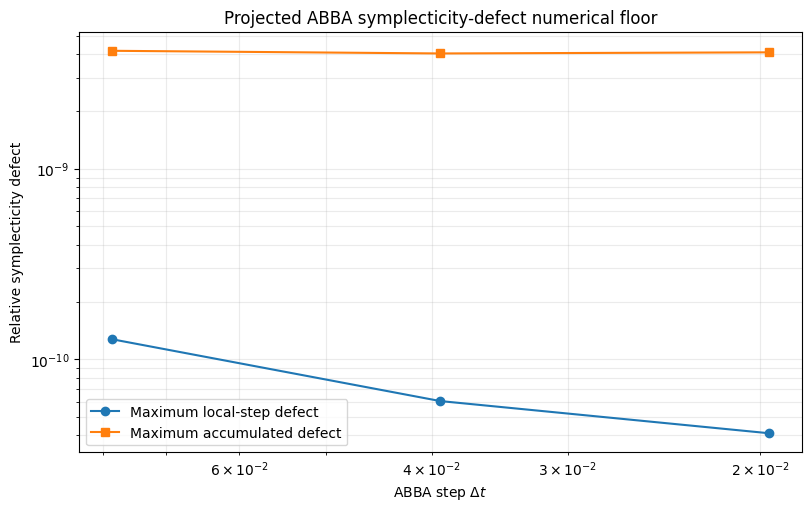

In [5]:
defect_floor_figure, defect_floor_axis = result.plot_defect_floor()

## Nonlinear projection diagnostics

The iteration and residual histories verify that the projection solve remains below its configured stopping threshold. The maximum multiplier is expected to decrease approximately as $O(h^3)$; this is a consistency property of the symmetric projection, not the global trajectory order.

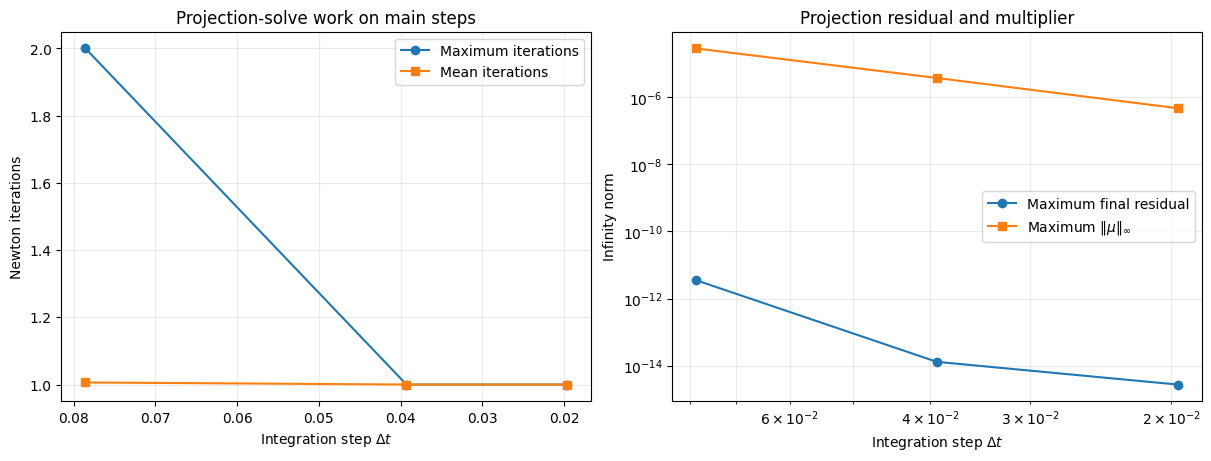

In [6]:
solver_figure, solver_axes = result.plot_solver_diagnostics()

## Comparative animation

The animation synchronizes the effective potential, transported ABBA contours, relative polygon-area error, and accumulated physical-flow symplecticity defect. The same color identifies each ABBA step size in every panel.

In [7]:
display_animation(
    result.animate(
        frames=None,
        interval=120,
    )
)

## Interpretation

The final interpretation is completed after executing the versioned experiment. It must distinguish the measured finite-difference floor from an exact symbolic proof, compare local and accumulated defects, verify the Newton solve and $O(h^3)$ multiplier scaling, and separate polygonal spatial error from temporal symplecticity.